## **Import Necessary Libraries and Modules**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

SEED = 42

## **Load and Prepare Data**

In [25]:
df = pd.read_csv("../encoded_dataset.csv")

display(df.head())

,timestamp,age,gender,college,year_of_study,gpa_range,currently_employed,leisure_hours,self_study_hours,study_environment,...,difficult_to_maintain,data_quality_check,comfort_or_convenience,peers_consider_normal,control_over_habit,sooner_next_month,delay_until_deadline,focus_frequency,delay_unenjoyable_assignments,referrer
0,2026-05-14 00:28:00,19,1,1,1,5,0,2.0,4.0,1.0,...,5,3,6,5,5,4,5,5.0,4.0,Nguyễn Cảnh Kỳ
1,2026-05-14 00:30:30,19,2,2,1,5,1,2.0,8.0,1.0,...,1,3,1,3,4,7,2,4.0,5.0,Đặng Tuấn Kiệt
2,2026-05-14 00:30:32,19,1,1,1,4,0,4.0,3.0,2.0,...,2,3,3,3,4,4,2,3.0,4.0,Đặng Tuấn Kiệt
3,2026-05-14 00:32:25,19,1,1,1,4,0,5.0,4.0,1.0,...,4,3,7,3,4,1,4,5.0,6.0,Nguyễn Trọng Nhân
4,2026-05-14 00:33:32,23,1,3,1,5,0,4.0,1.0,1.0,...,6,3,6,6,5,4,6,5.0,6.0,Bill


In [26]:
df.columns

Index(['timestamp', 'age', 'gender', 'college', 'year_of_study', 'gpa_range',
       'currently_employed', 'leisure_hours', 'self_study_hours',
       'study_environment', 'sleep_hours', 'impact_on_learning_progress',
       'far_away_deadlines', 'study_plan', 'start_early_when_necessary',
       'difficult_to_maintain', 'data_quality_check', 'comfort_or_convenience',
       'peers_consider_normal', 'control_over_habit', 'sooner_next_month',
       'delay_until_deadline', 'focus_frequency',
       'delay_unenjoyable_assignments', 'referrer'],
      dtype='str')

## **Feature and Binary Target Selection**

In [27]:
# ------------------- Binary Target Selection -----------------------
# >= 4 is 1 (procrastinate), < 4 is 0 (does not procrastinate)
target_feature = "delay_until_deadline"
y = (df[target_feature] >= 5).astype(int)


# ------------------- Feature Selection -----------------------------
drop_features = ["delay_until_deadline",
                 "timestamp",
                 "referrer",
                 "data_quality_check",
                 "delay_unenjoyable_assignments"]

# Filter out a list of 20 candidate features
candidate_features = df.drop(columns = drop_features).columns

# Assess the correlation of each feature with the target variable
features_correlation = []
for feature in candidate_features:
    correlation = df[feature].corr(df[target_feature])
    features_correlation.append({
        "Feature" : feature,
        "Correlation" : correlation,
        "Absolute Correlation" : abs(correlation)
    })

corr_df = pd.DataFrame(features_correlation).sort_values(by = "Absolute Correlation", ascending = False)
display(corr_df)

# Choose the top 15 features
top_15_features = corr_df.iloc[:15, 0]
display(top_15_features)

X = df[top_15_features]

,Feature,Correlation,Absolute Correlation
11,far_away_deadlines,0.471036,0.471036
15,comfort_or_convenience,0.456476,0.456476
14,difficult_to_maintain,0.384220,0.384220
6,leisure_hours,0.359945,0.359945
16,peers_consider_normal,0.325998,0.325998
7,self_study_hours,-0.315510,0.315510
17,control_over_habit,-0.260267,0.260267
10,impact_on_learning_progress,0.258609,0.258609
19,focus_frequency,-0.218111,0.218111
13,start_early_when_necessary,-0.187439,0.187439


11             far_away_deadlines
15         comfort_or_convenience
14          difficult_to_maintain
6                   leisure_hours
16          peers_consider_normal
7                self_study_hours
17             control_over_habit
10    impact_on_learning_progress
19                focus_frequency
13     start_early_when_necessary
4                       gpa_range
12                     study_plan
18              sooner_next_month
3                   year_of_study
2                         college
Name: Feature, dtype: str

## **Train/Test Split and Feature Scaling**

In [28]:
# ─────────────────────────────────────────────
# 2. Perform stratified train-test split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

print(f"Number of training samples is: {X_train.shape[0]}")
print(f"Number of testing_samples is: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Number of training samples is: 96
Number of testing_samples is: 97


## **Logistic Regression**

### **Baseline Models**

In [29]:
def predict_maximize_gmean(model, X, y_true):

    # 1. Get predicted probabilities for the positive class (column 1)
    y_scores = model.predict_proba(X)[:, 1]

    # Scenario A: We are calculating the optimal threshold dynamically (e.g., on a validation set)
    if y_true is not None:
        # Calculate True Positive Rate (Sensitivity) and False Positive Rate across thresholds
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)

        # Specificity is 1 - False Positive Rate
        specificity = 1 - fpr

        # Calculate G-Mean: sqrt(Sensitivity * Specificity)
        gmeans = np.sqrt(tpr * specificity)

        # Locate the index of the maximum G-Mean
        best_idx = np.argmax(gmeans)
        optimal_threshold = thresholds[best_idx]

        # Handle edge case where roc_curve arbitrarily sets the first threshold above 1.0
        if optimal_threshold > 1.0:
            optimal_threshold = 1.0

    # 2. Apply the optimal threshold to binarize predictions
    y_pred = (y_scores >= optimal_threshold).astype(int)

    return y_pred, optimal_threshold

In [30]:
logistic_regression_baseline = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_baseline.fit(X_train, y_train)
# Baseline AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_baseline.predict_proba(X_train)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_baseline.predict_proba(X_test)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(logistic_regression_baseline, X_test, y_test)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8791304347826087
Test AUC: 0.7612958226768969
Confusion matrix (test), threshold = 0.5408051324004971:
[[38 13]
 [15 31]]


In [31]:
logistic_regression_scaled = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_scaled.fit(X_train_sc, y_train)
# Scaled AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_scaled.predict_proba(X_train_sc)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_scaled.predict_proba(X_test_sc)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(
    logistic_regression_scaled, X_test_sc, y_test
)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8817391304347826
Test AUC: 0.7817561807331629
Confusion matrix (test), threshold = 0.5260801927787374:
[[39 12]
 [14 32]]


### **Hyperparameters Tuning**

In [32]:
def train_logistic(**kwargs):
    model = LogisticRegression(max_iter=1000, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

The optimum regularization strength c is: 1e-05


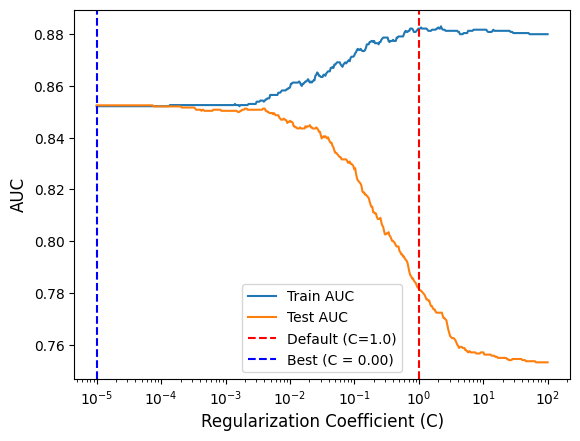

In [46]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 2, 500):
    model = train_logistic(C=C)
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax();
best_c = auc_df.loc[best_auc_idx, "C"]
print(f"The optimum regularization strength c is: {best_c}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)')
ax.axvline(x = best_c, color = 'blue', linestyle = '--', label = f"Best (C = {best_c:.2f})")
ax.set_xlabel('Regularization Coefficient (C)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.legend()
plt.savefig("../figures/logistic_auc.pdf", bbox_inches="tight")

## **SVM Model**

In [47]:
# ─────────────────────────────────────────────
# 1. Baseline SVM Model
# ─────────────────────────────────────────────

svm_baseline = SVC(probability=True, random_state = SEED)
svm_baseline.fit(X_train,y_train)

train_auc_score = roc_auc_score(y_train, svm_baseline.predict_proba(X_train)[:,1])
test_auc_score = roc_auc_score(y_test, svm_baseline.predict_proba(X_test)[:,1])

print(f"Train AUC: {train_auc_score:.4f}")
print(f"Test AUC:  {test_auc_score:.4f}")

Train AUC: 0.9513
Test AUC:  0.7899


In [48]:
# ─────────────────────────────────────────────
# 2. Baseline Scaled SVM Model
# ─────────────────────────────────────────────

svm_scaled_baseline = SVC(probability= True, random_state= SEED)
svm_scaled_baseline.fit(X_train_sc, y_train)

train_auc_scaled = roc_auc_score(y_train, svm_scaled_baseline.predict_proba(X_train_sc)[:,1])
test_auc_scaled = roc_auc_score(y_test, svm_scaled_baseline.predict_proba(X_test_sc)[:,1])

print(f"Train AUC: {train_auc_scaled:.4f}")
print(f"Test AUC:  {test_auc_scaled:.4f}")

Train AUC: 0.9739
Test AUC:  0.8124


In [49]:
def train_svm(**kwargs):
    model = SVC(probability=True, random_state=SEED, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

The optimum regularization strength c is: 0.005991769669310619


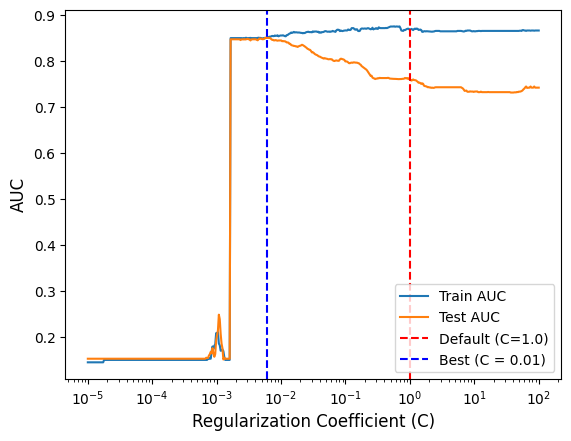

In [50]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 2, 500):
    model = train_svm(C=C, kernel = "linear", gamma = "scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax();
best_c = auc_df.loc[best_auc_idx, "C"]
print(f"The optimum regularization strength c is: {best_c}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)')
ax.axvline(x = best_c, color = 'blue', linestyle = '--', label = f"Best (C = {best_c:.2f})")
ax.set_xlabel('Regularization Coefficient (C)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.legend()
plt.savefig("../figures/linear_svm_auc.pdf", bbox_inches="tight")

The optimum regularization strength c is: 0.1838776980082327


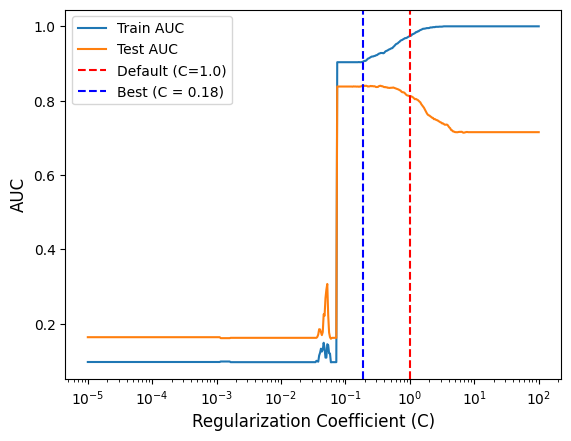

In [53]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 2, 500):
    model = train_svm(C=C, kernel = "rbf", gamma = "scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax();
best_c = auc_df.loc[best_auc_idx, "C"]
print(f"The optimum regularization strength c is: {best_c}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True)
ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)')
ax.axvline(x = best_c, color = 'blue', linestyle = '--', label = f"Best (C = {best_c:.2f})")
ax.set_xlabel('Regularization Coefficient (C)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.legend()
plt.savefig("../figures/rbf_svm_auc.pdf", bbox_inches="tight")

In [ ]:
# ─────────────────────────────────────────────
# 3. Train SVM
# ─────────────────────────────────────────────
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

y_train_pred = svm.predict(X_train_sc)
y_test_pred = svm.predict(X_test_sc)
y_test_prob = svm.predict_proba(X_test_sc)[:, 1]

In [ ]:
# ─────────────────────────────────────────────
# 4. Metrics
# ─────────────────────────────────────────────
def get_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─' * 40}")
    print(f"  {label} Metrics")
    print(f"{'─' * 40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1


train_metrics = get_metrics(y_train, y_train_pred, "Training Set")
test_metrics = get_metrics(y_test, y_test_pred, "Test Set")


────────────────────────────────────────
  Training Set Metrics
────────────────────────────────────────
  Accuracy  : 0.9375
  Precision : 0.9545
  Recall    : 0.9130
  F1-Score  : 0.9333

────────────────────────────────────────
  Test Set Metrics
────────────────────────────────────────
  Accuracy  : 0.7732
  Precision : 0.8000
  Recall    : 0.6957
  F1-Score  : 0.7442


In [ ]:
print("\nClassification Report (Train Set):")
print(
    classification_report(
        y_train, y_train_pred, target_names=["Not Procrastinate", "Procrastinate"]
    )
)

print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Not Procrastinate", "Procrastinate"]
    )
)


Classification Report (Train Set):
                   precision    recall  f1-score   support

Not Procrastinate       0.92      0.96      0.94        50
    Procrastinate       0.95      0.91      0.93        46

         accuracy                           0.94        96
        macro avg       0.94      0.94      0.94        96
     weighted avg       0.94      0.94      0.94        96


Classification Report (Test Set):
                   precision    recall  f1-score   support

Not Procrastinate       0.75      0.84      0.80        51
    Procrastinate       0.80      0.70      0.74        46

         accuracy                           0.77        97
        macro avg       0.78      0.77      0.77        97
     weighted avg       0.78      0.77      0.77        97

